# Australian Crime Offender Analysis

## Notebook 2: Exploratory Crime Analysis

This notebook analyses Australian offender statistics from 2008–09 to 2024–25.

Objectives:

- Identify long-term offender trends
- Compare offence categories
- Analyse changes over time
- Identify offences increasing or decreasing
- Generate insights for dashboard development

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

pd.set_option(
    "display.max_columns",
    None
)

## Load Processed Dataset

The analysis uses the validated dataset generated by the ETL pipeline.

In [21]:
df = pd.read_csv(
    "../data/processed/offenders_clean.csv"
)

df.head()

,Offence_Category,Year,Offender_Count,Offender_Rate
0,01 Homicide and related offences(e),2008–09,816.0,4.4
1,011 Murder,2008–09,318.0,1.7
2,012 Attempted Murder,2008–09,232.0,1.2
3,013 Manslaughter and driving causing death,2008–09,260.0,1.4
4,02 Acts intended to cause injury(f),2008–09,72069.0,384.9


In [22]:
df.shape

(629, 4)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Offence_Category  629 non-null    str    
 1   Year              629 non-null    str    
 2   Offender_Count    629 non-null    float64
 3   Offender_Rate     629 non-null    float64
dtypes: float64(2), str(2)
memory usage: 43.9 KB


## Total Offender Trend Over Time

In [24]:
annual_totals = (
    df.groupby("Year")
    ["Offender_Count"]
    .sum()
    .reset_index()
)

annual_totals

,Year,Offender_Count
0,2008–09,655770.0
1,2009–10,689419.0
2,2010–11,680066.0
3,2011–12,668513.0
4,2012–13,696041.0
5,2013–14,689631.0
6,2014–15,678061.0
7,2015–16,681631.0
8,2016–17,672010.0
9,2017–18,669063.0


In [25]:
percentage_change = (
    (
        annual_totals.iloc[-1]["Offender_Count"]
        -
        annual_totals.iloc[0]["Offender_Count"]
    )
    /
    annual_totals.iloc[0]["Offender_Count"]
    *
    100
)

print(f"{percentage_change:.1f}%")

-12.2%


### Insight

Total offender numbers declined approximately 12.2% between 2008–09 and 2024–25.

The largest reductions occurred after 2018–19, with offender numbers reaching their lowest point in 2023–24 before slightly increasing in 2024–25.

## Visualise National Trend

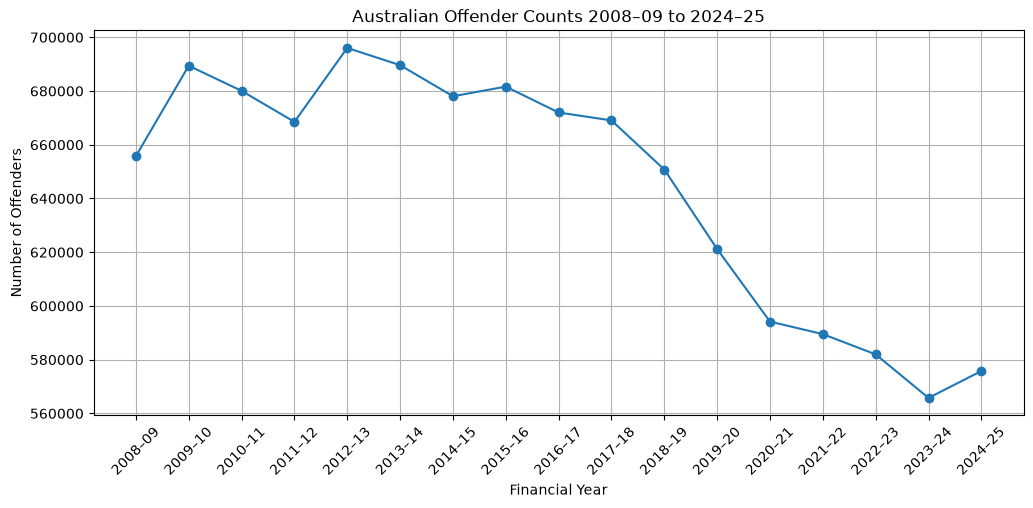

In [26]:
plt.figure(figsize=(12,5))

plt.plot(
    annual_totals["Year"],
    annual_totals["Offender_Count"],
    marker="o"
)

plt.xticks(
    rotation=45
)

plt.title(
    "Australian Offender Counts 2008–09 to 2024–25"
)

plt.xlabel(
    "Financial Year"
)

plt.ylabel(
    "Number of Offenders"
)

plt.grid()

plt.show()

## Offence Category Analysis

In [27]:
category_totals = (
    df.groupby(
        "Offence_Category"
    )
    ["Offender_Count"]
    .sum()
    .sort_values(
        ascending=False
    )
)

category_totals

Offence_Category
02 Acts intended to cause injury(f)               1336544.0
021 Assault                                       1236151.0
10 Illicit drug offences(l)                       1108940.0
13 Public order offences(m)                        958762.0
08 Theft(i)(j)                                     774669.0
104 Possess and/or use illicit drugs               739170.0
082 Theft (except motor vehicles)                  612019.0
15 Offences against justice(n)(o)                  461810.0
131 Disorderly conduct                             422285.0
16 Miscellaneous offences                          362893.0
12 Property damage and environmental pollution     281083.0
132 Regulated public order offences                279287.0
133 Offensive conduct                              256591.0
153 Breach of violence and non-violence orders     231754.0
07 Unlawful entry with intent                      212492.0
11 Weapons/explosives                              207692.0
156 Offences against ju

## Top Offence Categories Chart

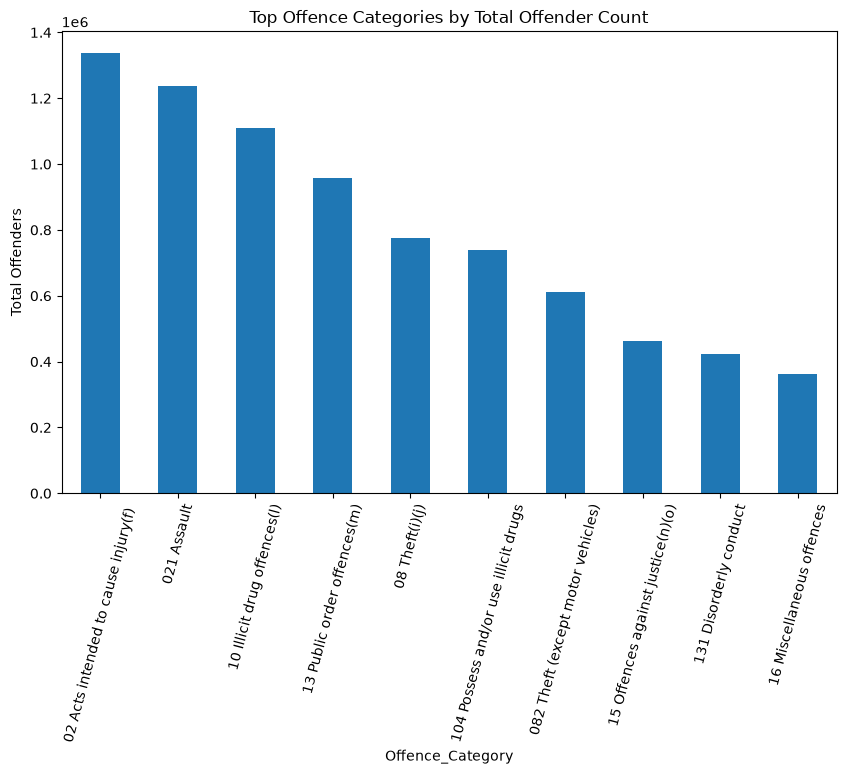

In [28]:
plt.figure(figsize=(10,6))

category_totals.head(10).plot(
    kind="bar"
)

plt.title(
    "Top Offence Categories by Total Offender Count"
)

plt.ylabel(
    "Total Offenders"
)

plt.xticks(
    rotation=75
)

plt.show()

## Long Term Category Change

In [29]:
category_change = (
    df.groupby(
        "Offence_Category"
    )
    .agg(
        start_count=(
            "Offender_Count",
            "first"
        ),
        end_count=(
            "Offender_Count",
            "last"
        )
    )
)


category_change["Change"] = (
    category_change["end_count"]
    -
    category_change["start_count"]
)


category_change.sort_values(
    "Change",
    ascending=False
)

,start_count,end_count,Change
Offence_Category,,,
02 Acts intended to cause injury(f),72069.0,98530.0,26461.0
021 Assault,69218.0,88148.0,18930.0
153 Breach of violence and non-violence orders,7332.0,20800.0,13468.0
11 Weapons/explosives,8962.0,16769.0,7807.0
029 Other acts intended to cause injury,2728.0,10367.0,7639.0
15 Offences against justice(n)(o),26201.0,32081.0,5880.0
03 Sexual assault and related offences(g),6340.0,10052.0,3712.0
032 Non–assaultive sexual offences,1363.0,3476.0,2113.0
031 Sexual assault,4979.0,6572.0,1593.0


## Rate Analysis

In [30]:
latest_year = (
    df[df["Year"]=="2024–25"]
)


latest_rates = (
    latest_year
    [
        [
        "Offence_Category",
        "Offender_Rate"
        ]
    ]
    .sort_values(
        "Offender_Rate",
        ascending=False
    )
)

latest_rates

,Offence_Category,Offender_Rate
596,02 Acts intended to cause injury(f),405.9
597,021 Assault,363.2
615,10 Illicit drug offences(l),195.9
606,08 Theft(i)(j),145.3
625,15 Offences against justice(n)(o),132.2
618,104 Possess and/or use illicit drugs,130.3
621,13 Public order offences(m),127.5
608,082 Theft (except motor vehicles),108.2
626,153 Breach of violence and non-violence orders,85.7
622,131 Disorderly conduct,75.1


# Key Findings

## Overall Trend

Australian offender numbers declined approximately 12% from 2008–09 to 2024–25.

## Highest Volume Offences

Acts intended to cause injury consistently represents the largest offender category.

## Increasing Offence Areas

The largest increases occurred in:

- Acts intended to cause injury
- Weapons offences
- Justice offences
- Sexual assault offences

## Declining Areas

Major declines occurred in:

- Public order offences
- Theft
- Miscellaneous offences
- Illicit drug offences

## Dashboard Implication

The dashboard should prioritise:

- Overall offender trend
- Category comparison
- Year-on-year changes
- Offence rate comparison

## Year-on-Year Change Analysis

In [31]:
annual_totals["Yearly_Change"] = (
    annual_totals["Offender_Count"]
    .diff()
)

annual_totals

,Year,Offender_Count,Yearly_Change
0,2008–09,655770.0,NaN
1,2009–10,689419.0,33649.0
2,2010–11,680066.0,-9353.0
3,2011–12,668513.0,-11553.0
4,2012–13,696041.0,27528.0
5,2013–14,689631.0,-6410.0
6,2014–15,678061.0,-11570.0
7,2015–16,681631.0,3570.0
8,2016–17,672010.0,-9621.0
9,2017–18,669063.0,-2947.0


In [32]:
largest_increases = (
    annual_totals
    .sort_values(
        "Yearly_Change",
        ascending=False
    )
    .head(5)
)

largest_increases

,Year,Offender_Count,Yearly_Change
1,2009–10,689419.0,33649.0
4,2012–13,696041.0,27528.0
16,2024–25,575773.0,10008.0
7,2015–16,681631.0,3570.0
9,2017–18,669063.0,-2947.0


In [33]:
largest_decreases = (
    annual_totals
    .sort_values(
        "Yearly_Change"
    )
    .head(5)
)

largest_decreases

,Year,Offender_Count,Yearly_Change
11,2019–20,621195.0,-29592.0
12,2020–21,594183.0,-27012.0
10,2018–19,650787.0,-18276.0
15,2023–24,565765.0,-16213.0
6,2014–15,678061.0,-11570.0


## Year-on-Year Change

The largest annual decreases occurred during the late 2010s and early 2020s.

This period coincides with a substantial reduction in overall offender counts.

The 2024–25 period shows a recovery from the previous year, suggesting offender numbers may have stabilised after reaching a recent low point.

## Highest and Lowest Offender Years

In [34]:
highest_year = (
    annual_totals
    .loc[
        annual_totals["Offender_Count"]
        .idxmax()
    ]
)


lowest_year = (
    annual_totals
    .loc[
        annual_totals["Offender_Count"]
        .idxmin()
    ]
)


highest_year, lowest_year

(Year               2012–13
 Offender_Count    696041.0
 Yearly_Change      27528.0
 Name: 4, dtype: object,
 Year               2023–24
 Offender_Count    565765.0
 Yearly_Change     -16213.0
 Name: 15, dtype: object)

## Extremes

The highest offender count occurred in 2012–13.

The lowest offender count occurred in 2023–24, representing a decline of approximately 130,000 offenders compared with the peak period.

## Offence Category Trends Over Time

In [35]:
top_categories = (
    category_totals
    .head(5)
    .index
)


top_categories

Index(['02 Acts intended to cause injury(f) ', '021 Assault',
       '10 Illicit drug offences(l)', '13 Public order offences(m)',
       '08 Theft(i)(j)'],
      dtype='str', name='Offence_Category')

In [36]:
trend_categories = df[
    df["Offence_Category"]
    .isin(top_categories)
]


trend_categories.head()

,Offence_Category,Year,Offender_Count,Offender_Rate
4,02 Acts intended to cause injury(f),2008–09,72069.0,384.9
5,021 Assault,2008–09,69218.0,369.6
14,08 Theft(i)(j),2008–09,58941.0,314.8
23,10 Illicit drug offences(l),2008–09,56310.0,300.7
29,13 Public order offences(m),2008–09,65962.0,352.2


In [37]:
category_trends = (
    trend_categories
    .pivot(
        index="Year",
        columns="Offence_Category",
        values="Offender_Count"
    )
)


category_trends

Offence_Category,02 Acts intended to cause injury(f),021 Assault,08 Theft(i)(j),10 Illicit drug offences(l),13 Public order offences(m)
Year,,,,,
2008–09,72069.0,69218.0,58941.0,56310.0,65962.0
2009–10,72280.0,69079.0,64382.0,57899.0,75200.0
2010–11,70573.0,67219.0,64806.0,58700.0,73845.0
2011–12,68476.0,64981.0,64587.0,60729.0,69442.0
2012–13,70371.0,66406.0,62520.0,65346.0,73940.0
2013–14,71395.0,67081.0,47913.0,73300.0,77043.0
2014–15,72721.0,68002.0,39424.0,81161.0,69982.0
2015–16,76206.0,70986.0,42060.0,83204.0,64014.0
2016–17,78421.0,72964.0,42221.0,81160.0,61198.0


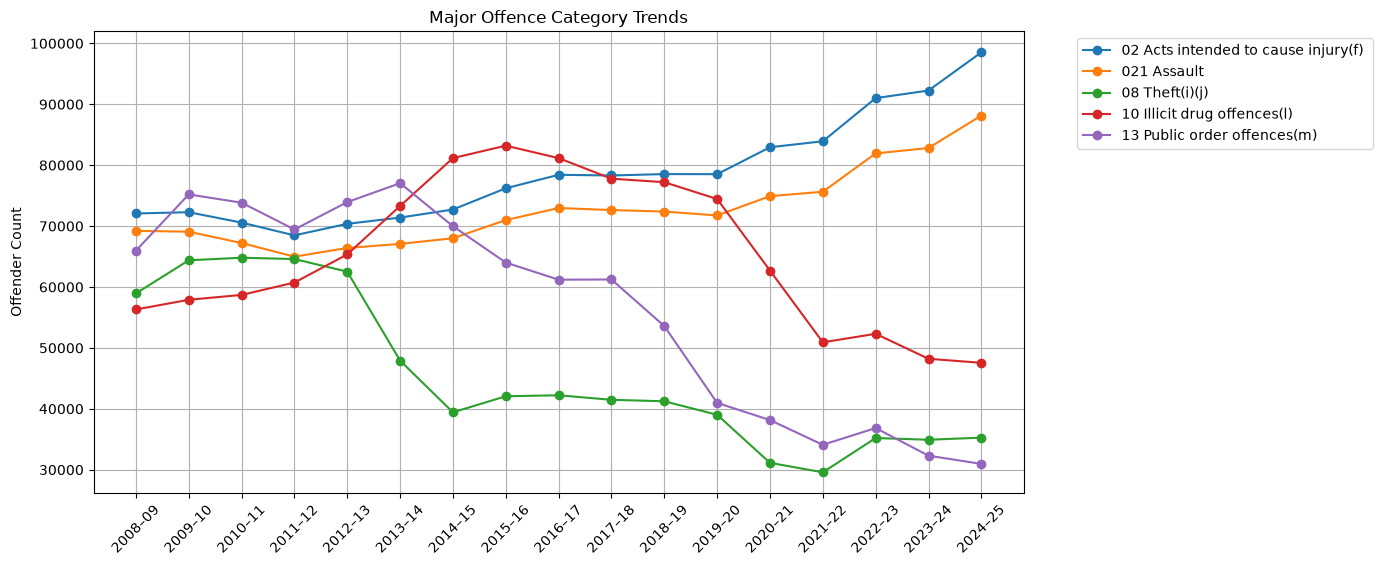

In [38]:
plt.figure(figsize=(12,6))


for column in category_trends.columns:
    plt.plot(
        category_trends.index,
        category_trends[column],
        marker="o",
        label=column
    )


plt.xticks(
    rotation=45
)

plt.title(
    "Major Offence Category Trends"
)

plt.ylabel(
    "Offender Count"
)

plt.legend(
    bbox_to_anchor=(1.05,1)
)

plt.grid()

plt.show()

## Offence Subcategory Analysis

In [39]:
subcategory_totals = (
    df.groupby(
        "Offence_Category"
    )
    ["Offender_Count"]
    .sum()
    .sort_values(
        ascending=False
    )
)


subcategory_totals.head(20)

Offence_Category
02 Acts intended to cause injury(f)               1336544.0
021 Assault                                       1236151.0
10 Illicit drug offences(l)                       1108940.0
13 Public order offences(m)                        958762.0
08 Theft(i)(j)                                     774669.0
104 Possess and/or use illicit drugs               739170.0
082 Theft (except motor vehicles)                  612019.0
15 Offences against justice(n)(o)                  461810.0
131 Disorderly conduct                             422285.0
16 Miscellaneous offences                          362893.0
12 Property damage and environmental pollution     281083.0
132 Regulated public order offences                279287.0
133 Offensive conduct                              256591.0
153 Breach of violence and non-violence orders     231754.0
07 Unlawful entry with intent                      212492.0
11 Weapons/explosives                              207692.0
156 Offences against ju

In [40]:
subcategories = (
    df[
        ~df["Offence_Category"]
        .str.match(r"^\d{2}\s")
    ]
)


subcategories.head()

,Offence_Category,Year,Offender_Count,Offender_Rate
1,011 Murder,2008–09,318.0,1.7
2,012 Attempted Murder,2008–09,232.0,1.2
3,013 Manslaughter and driving causing death,2008–09,260.0,1.4
5,021 Assault,2008–09,69218.0,369.6
6,029 Other acts intended to cause injury,2008–09,2728.0,14.6


In [41]:
(
    subcategories
    .groupby(
        "Offence_Category"
    )
    ["Offender_Count"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(15)
)

Offence_Category
021 Assault                                       1236151.0
104 Possess and/or use illicit drugs               739170.0
082 Theft (except motor vehicles)                  612019.0
131 Disorderly conduct                             422285.0
132 Regulated public order offences                279287.0
133 Offensive conduct                              256591.0
153 Breach of violence and non-violence orders     231754.0
156 Offences against justice procedures            182438.0
102 Deal or traffic in illicit drugs               145662.0
091 Obtain benefit by deception                    132832.0
029 Other acts intended to cause injury             99998.0
031 Sexual assault                                  94832.0
103 Manufacture or cultivate illicit drugs          91220.0
081 Motor vehicle theft                             83997.0
083 Receive or handle proceeds of crime             69178.0
Name: Offender_Count, dtype: float64

## Rate vs Count Comparison

In [42]:
comparison = (
    df[df["Year"]=="2024–25"]
    [
        [
            "Offence_Category",
            "Offender_Count",
            "Offender_Rate"
        ]
    ]
    .sort_values(
        "Offender_Count",
        ascending=False
    )
)


comparison

,Offence_Category,Offender_Count,Offender_Rate
596,02 Acts intended to cause injury(f),98530.0,405.9
597,021 Assault,88148.0,363.2
615,10 Illicit drug offences(l),47550.0,195.9
606,08 Theft(i)(j),35266.0,145.3
625,15 Offences against justice(n)(o),32081.0,132.2
618,104 Possess and/or use illicit drugs,31636.0,130.3
621,13 Public order offences(m),30952.0,127.5
608,082 Theft (except motor vehicles),26266.0,108.2
626,153 Breach of violence and non-violence orders,20800.0,85.7
622,131 Disorderly conduct,18219.0,75.1


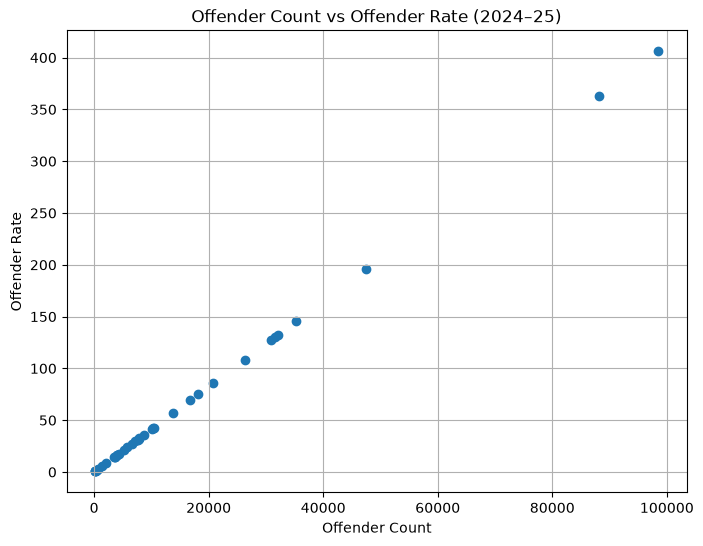

In [43]:
plt.figure(figsize=(8,6))


plt.scatter(
    comparison["Offender_Count"],
    comparison["Offender_Rate"]
)


plt.xlabel(
    "Offender Count"
)

plt.ylabel(
    "Offender Rate"
)

plt.title(
    "Offender Count vs Offender Rate (2024–25)"
)


plt.grid()

plt.show()

## Analytical Summary Table

In [44]:
summary = (
    df[df["Year"]=="2024–25"]
    .sort_values(
        "Offender_Count",
        ascending=False
    )
    [
        [
        "Offence_Category",
        "Offender_Count",
        "Offender_Rate"
        ]
    ]
)


summary

,Offence_Category,Offender_Count,Offender_Rate
596,02 Acts intended to cause injury(f),98530.0,405.9
597,021 Assault,88148.0,363.2
615,10 Illicit drug offences(l),47550.0,195.9
606,08 Theft(i)(j),35266.0,145.3
625,15 Offences against justice(n)(o),32081.0,132.2
618,104 Possess and/or use illicit drugs,31636.0,130.3
621,13 Public order offences(m),30952.0,127.5
608,082 Theft (except motor vehicles),26266.0,108.2
626,153 Breach of violence and non-violence orders,20800.0,85.7
622,131 Disorderly conduct,18219.0,75.1


# Final Analysis Summary

## National Trend

Australian offender numbers declined by approximately 12% between 2008–09 and 2024–25.

## Dominant Offence Categories

Acts intended to cause injury remained the largest offender category throughout the period.

Other high-volume categories included:

- Illicit drug offences
- Theft
- Justice offences
- Public order offences

## Long-Term Increases

The strongest growth occurred in:

- Acts intended to cause injury
- Weapons offences
- Sexual assault offences

## Long-Term Declines

The largest reductions occurred in:

- Public order offences
- Theft
- Miscellaneous offences
- Illicit drug offences

## Dashboard Design Implications

The final dashboard should include:

- National offender trend
- Offence category comparison
- Category change over time
- Offender rate comparison
- Filters by year and offence category

In [45]:
from pathlib import Path

analytics_path = Path(
    "../data/analytics"
)

analytics_path.mkdir(
    exist_ok=True
)

In [46]:
annual_totals.to_csv(
    analytics_path / "annual_totals.csv",
    index=False
)

In [47]:
category_totals.to_csv(
    analytics_path / "category_totals.csv"
)

In [48]:
category_change.to_csv(
    analytics_path / "category_change.csv"
)

In [49]:
latest_rates.to_csv(
    analytics_path / "latest_rates.csv",
    index=False
)

# Notebook 2 Conclusion

This analysis identified key patterns in Australian offender statistics between 2008–09 and 2024–25.

Major findings:

- Total offender numbers declined by approximately 12%.
- Acts intended to cause injury remained the largest offence category.
- Theft and public order offences experienced substantial declines.
- Weapons and injury-related offences increased over the study period.
- Offender rates highlight differences between absolute volume and population-adjusted impact.

These findings inform the design requirements for the interactive dashboard.